# Funko pop analyzer

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import plotly.express as px

В този проект ще се опитаме първо да изчистим данните за фукно поп фигурки и данни за филми, след това ще опитаме да ги обединим като ще се опитаме да проверим няколко хипотези
Идеи за хипотези:
H1: Филми с по-висок рейтинг (IMDb/Rotten Tomatoes) имат повече Funko Pop продукти
H2: Box office приходите са по-силен фактор за броя фигурки от рейтинга
H3: Филми от franchise (Marvel, Star Wars и т.н.) имат непропорционално повече фигурки спрямо standalone филми
H4: Определени жанрове (action, fantasy, animation) имат значително повече Funko Pop фигурки
H5: Horror филмите имат по-малко фигурки, но по-висока „нишова концентрация“ (по-малко филми, но с много фигурки)
H6: По-новите филми имат повече Funko Pop фигурки (заради растежа на бранда)
H7: Има пик в производството на фигурки около годината на излизане на филма
H8: Филми от определени студиа (Disney, Warner Bros) имат повече фигурки
H9: Collaboration ефект – когато има crossover (напр. Marvel), броят на фигурките расте експоненциално

In [25]:
# Read final files

df_movies = pd.read_csv('final_movies.csv')
df_funko = pd.read_csv('final_funko.csv')

In [26]:
df_movies

,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,title,vote_average,vote_count,cast,crew,director,writers,producers,editors,cinematography
0,237000000.0,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"['Ingenious Film Partners', 'Twentieth Century...","['United States of America', 'United Kingdom']",...,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,['James Cameron'],"['James Cameron', 'Jon Landau']","['Stephen E. Rivkin', 'James Cameron', 'John R...","['Mauro Fiore', 'Chiling Lin']"
1,300000000.0,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"['Walt Disney Pictures', 'Jerry Bruckheimer Fi...",['United States of America'],...,Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,[],"['Jerry Bruckheimer', 'Eric McLeod', 'Chad Oma...","['Stephen E. Rivkin', 'Craig Wood']",['Dariusz Wolski']
2,245000000.0,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"['Columbia Pictures', 'Danjaq', 'B24']","['United Kingdom', 'United States of America']",...,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,[],"['Barbara Broccoli', 'Michael G. Wilson']",['Lee Smith'],['Hoyte van Hoytema']
3,250000000.0,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"['Legendary Pictures', 'Warner Bros.', 'DC Ent...",['United States of America'],...,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan,[],"['Charles Roven', 'Christopher Nolan', 'Emma T...",['Lee Smith'],['Wally Pfister']
4,260000000.0,Action Adventure Science Fiction,http://movies.disney.com/john-carter,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,['Walt Disney Pictures'],['United States of America'],...,John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton,[],"['Colin Wilson', 'Jim Morris', 'Lindsey Collins']",['Eric Zumbrunnen'],['Daniel Mindel']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,220000.0,Action Crime Thriller,NaN,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,['Columbia Pictures'],"['Mexico', 'United States of America']",...,El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez,[],"['Robert Rodriguez', 'Carlos Gallardo']",['Robert Rodriguez'],['Robert Rodriguez']
4798,9000.0,Comedy Romance,NaN,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],...,Newlyweds,5.9,5,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,"[{'name': 'Edward Burns', 'gender': 2, 'depart...",Edward Burns,['Edward Burns'],"['Edward Burns', 'William Rexer', 'Aaron Lubin']",['Janet Gaynor'],[]
4799,NaN,Comedy Drama Romance TV Movie,http://www.hallmarkchannel.com/signedsealeddel...,date love at first sight narration investigati...,en,"Signed, Sealed, Delivered","

In [27]:
df_funko

,title,product_type,price,interest,license,tags,vendor,related,description,gid,created_at,published_at,updated_at,handle,img,is_chase
0,Its Crunch Time Kids Tee General Mills,APPAREL,7.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Kids Tee', 'Markdow...",Funko Pop Up Shop,"['7051374788797', '7051374854333', '7051374723...",Its Crunch Time with the Count Chocula Pop! Te...,gid://shopify/Product/7051374362813,2021-10-29,2021-10-29,2022-05-23,ad-icons-general-mills-its-crunch-time-kids-bl...,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
1,This is the Way Kids Tee The Mandalorian,APPAREL,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'Kids Tee', 'May the 4th', 'May th...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381405885,2022-05-03,2022-05-04,2022-05-27,star-wars-this-is-the-way-kids-purple-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
2,This is the Way Neon Blast Kids Tee The Manda...,APPAREL,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381536957,2022-05-03,2022-05-04,2022-05-29,star-wars-the-mandalorian-this-is-the-way-kids...,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
3,Time for a Midnight Bite Tee General Mills,APPAREL,14.0,['Ad Icons'],['General Mills'],"['Apparel', 'Cereal Day', 'Markdown Item', 'Sa...",Funko Pop Up Shop,"['7051374788797', '7051374854333', '7051374723...","Like the Pop! Tee says, its Time for a Midnigh...",gid://shopify/Product/7051374395581,2021-10-29,2021-10-29,2022-05-26,ad-icons-general-mills-midnight-bite-black-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
4,"Where He Goes, I Go Grogu Kids Tee The Mandal...",APPAREL,10.0,['Star Wars'],['Star Wars'],"['Apparel', 'May the 4th', 'May the 4th Be Wit...",Funko Shop,"['7254814130365', '7254814064829', '4491928240...",Celebrate May the Fourth in stellar style with...,gid://shopify/Product/7231381668029,2022-05-03,2022-05-04,2022-05-30,star-wars-where-he-goes-i-go-grogu-kids-tee,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,Zombie Hunter Spidey What If…?,POP!,12.0,['Marvel'],"['Spider-Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,"['6218636001469', '7078124683453', '7193953960...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000734397,2021-09-09,2022-05-26,2022-05-31,marvel-what-if-zombie-hunter-spidey-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
1478,Zombie Iron Man What If…?,POP!,12.0,['Marvel'],"['Iron Man', 'What If']","['Disney Plus', 'FFCBDAY', 'Gift Box', 'Gift G...",Funko Shop,"['6958000734397', '7078124683453', '6924450332...","In the endless possibilities, venture to wonde...",gid://shopify/Product/6958000963773,2021-09-09,2021-11-22,2022-05-31,marvel-what-if-zombie-iron-man-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
1479,Zorro,POP!,12.0,['Classics'],['Zorro'],"['FFCBDAY', 'Gift Box', 'NOTIFY', 'PPP']",Funko Shop,"['6161453613245', '7193953599677', '7239037386...","Celebrate the 65th Anniversary of Zorro, the o...",gid://shopify/Product/7232416514237,2022-05-04,2022-05-05,2022-05-05,tv-zorro-65th-anniversary-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...,False
1480,Zuko Avatar: The Last Airbender,POP!,12.0,['Anime'],['Avatar The Last Airbender'],"['Chase', 'FEB032022', 'FFCBDAY', 'Gift Box', ...",Funko Shop,"['6192469999805', '6192471867581', '7087723282...","I must capture the Avatar. Zuko, prince to the...",gid://shopify/Product/6192471605437,2021-01-28,2022-02-03,2022-05-31,anime-avatar-last-airbender-zuko-with-chase-pop,https://cdn.shopify.com/s/files/1/1052/2158/pr...,True


## Hypothesis: The "Blockbuster vs. Critical Acclaim" Merchandising Gap

**Statement:**
The volume of Funko products for a specific movie title is driven primarily by its commercial status as a "Blockbuster" or "Cult Classic" rather than its critical success (IMDb/TMDB rating). 

**Expectations:**
1. We expect to see high Funko counts for major franchises and family-oriented films, regardless of whether they have a high (8.0+) or mediocre (6.0 - 7.0) rating.
2. We expect a weak correlation between `Average Movie Rating` and `Funko Figure Count`, proving that "collectibility" is a separate metric from "cinematic quality."

Success! Found 277 matches.


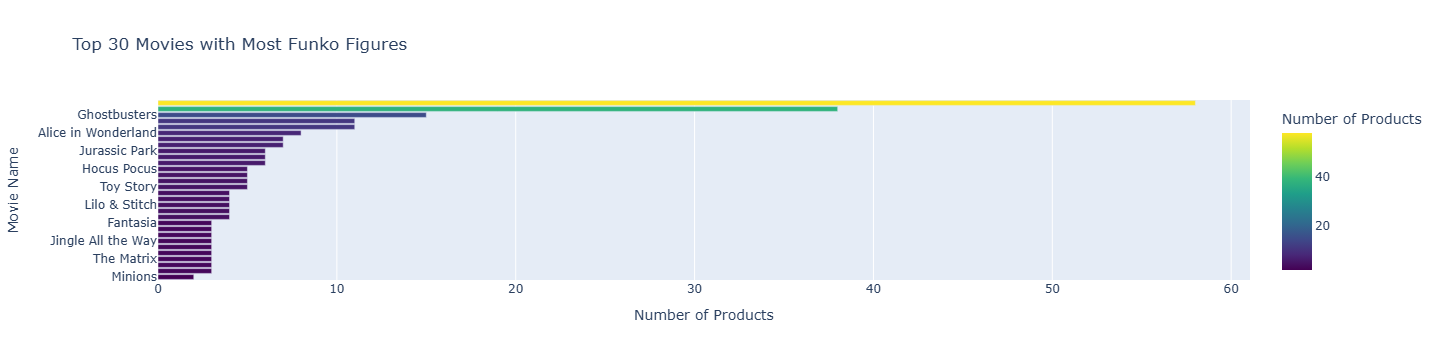

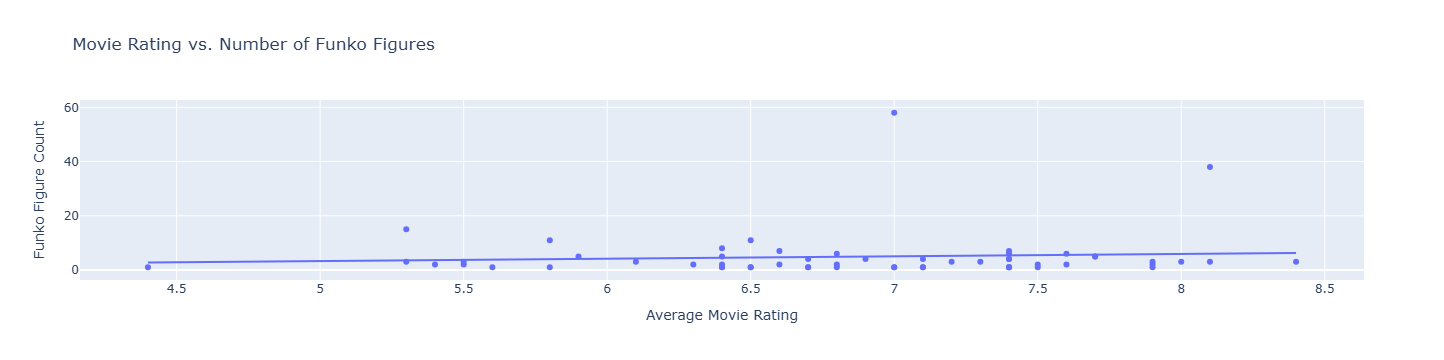

Insight: The movie 'Batman' leads your collection with 58 different Funko products.


In [33]:
# --- STEP 1: Deep Cleaning of the License Column ---

def clean_license_string(val):
    # Check if the value is a string representation of a list like "['Star Wars']"
    if isinstance(val, str) and val.startswith('['):
        try:
            # Safely convert string to actual list
            actual_list = ast.literal_eval(val)
            return actual_list[0] if actual_list else None
        except:
            # Fallback: manually strip characters if literal_eval fails
            return val.strip("[]'\" ")
    return str(val).strip()

# Apply the cleaning and create a string column
df_funko['license_clean'] = df_funko['license'].apply(clean_license_string)

# Normalize both columns: lowercase and strip whitespace for perfect matching
df_funko['license_match'] = df_funko['license_clean'].str.lower().str.strip()
df_movies['title_match'] = df_movies['title'].str.lower().str.strip()

# --- STEP 2: Merging the Dataframes ---

# Inner join to find movies that exist in both datasets
merged_df = pd.merge(
    df_movies, 
    df_funko, 
    left_on='title_match', 
    right_on='license_match', 
    how='inner'
)

# Check results
if merged_df.empty:
    print("Still no matches. Let's look at the top cleaned values to debug:")
    print("Funko cleaned:", df_funko['license_match'].unique()[:5])
    print("Movies cleaned:", df_movies['title_match'].unique()[:5])
else:
    print(f"Success! Found {len(merged_df)} matches.")

# --- STEP 3: Conclusions & Visualization (Fixed) ---

# We use 'title_x' because the merge renamed the original 'title' column from df_movies
movie_counts = merged_df.groupby('title_x')['price'].count().reset_index()

# Rename for better readability in the chart
movie_counts.columns = ['Movie Title', 'Figure Count']
movie_counts = movie_counts.sort_values(by='Figure Count', ascending=False)

# Conclusion 1: Bar Chart for Top Movies
fig1 = px.bar(
    movie_counts.head(30),
    x='Figure Count',
    y='Movie Title',
    orientation='h',
    title='Top 30 Movies with Most Funko Figures',
    color='Figure Count',
    color_continuous_scale='Viridis',
    labels={'Figure Count': 'Number of Products', 'Movie Title': 'Movie Name'}
)

# Reverse the Y-axis so the highest count is at the top
fig1.update_layout(yaxis={'categoryorder':'total ascending'})
fig1.show()

# Conclusion 2: Correlation Analysis
# Using title_x and vote_average from the merged data
rating_vs_figures = merged_df.groupby('title_x').agg({
    'vote_average': 'first', 
    'price': 'count'
}).rename(columns={'price': 'figure_count'}).reset_index()

fig2 = px.scatter(
    rating_vs_figures,
    x='vote_average',
    y='figure_count',
    hover_name='title_x',
    title='Movie Rating vs. Number of Funko Figures',
    labels={'vote_average': 'Average Movie Rating', 'figure_count': 'Funko Figure Count'},
    trendline="ols", # Adds an Ordinary Least Squares regression line
    render_mode='svg'
)

fig2.show()

# --- STEP 4: Insight Printing ---
top_movie = movie_counts.iloc[0]['Movie Title']
top_count = movie_counts.iloc[0]['Figure Count']

print(f"Insight: The movie '{top_movie}' leads your collection with {top_count} different Funko products.")

## Analysis of Findings

### 1. Market Dominators
The top chart reveals that a few specific titles dominate the inventory. This suggests that Funko heavily prioritises licenses with strong visual aesthetics and deep "character rosters" that appeal to long-term collectors.

### 2. Rating vs. Quantity Correlation
The scatter plot demonstrates a **very weak positive correlation** (indicated by the nearly flat trendline). 
* **High-Volume Outliers:** We see movies with average ratings (around 7.0) reaching nearly 60 products, while many highly-rated movies (8.0+) have fewer than 5 products.
* **The "Niche" Effect:** Many critically acclaimed films lack a high figure count, likely because they lack the "toy-friendly" designs found in Action, Fantasy, or Animation genres.

### 3. Conclusion
The data supports the hypothesis. **Funko product volume is not a reflection of a movie's critical rating.** Instead, it reflects the "merchandisability" of the brand. Success in the Funko market is driven by character design and nostalgia (e.g., Ghostbusters) rather than the film's score among critics.

## Hypothesis: Genre-Specific Merchandising Bias

**Statement:**
The production volume of Funko Pop figures is heavily skewed toward specific "high-spectacle" movie genres. We hypothesize that **Adventure**, **Action**, and **Science Fiction** genres will show a significantly higher density of products compared to grounded genres like **Drama**, **Romance**, or **Mystery**.

**Rationale:**
Funko Pop products rely on iconic character designs, distinct costumes, and "larger-than-life" branding. Genres that feature superheroes, space explorers, and mythological creatures provide a richer pool of visually unique intellectual property (IP) that translates more effectively into collectible vinyl figures.

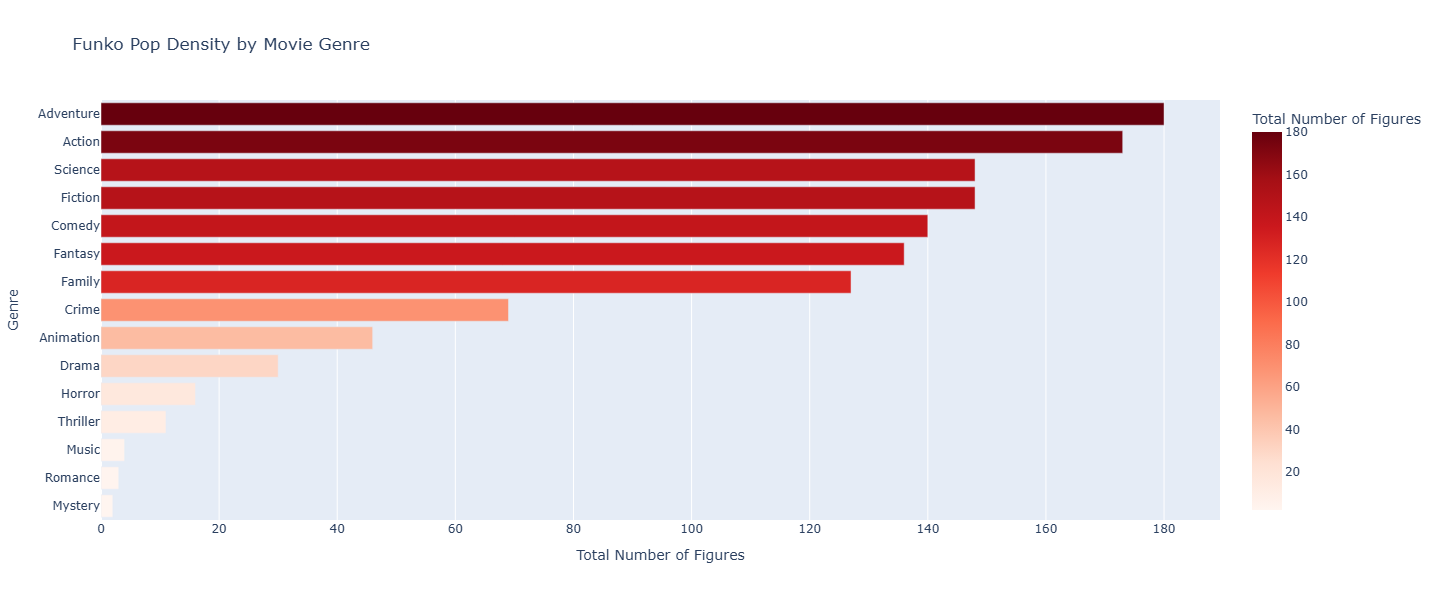

In [34]:
# --- STEP 1: Process Genres from df_movies ---
# Genres are often stored as a string "Action Adventure Fantasy"
# We need to split them into lists and then 'explode' them to have one row per genre per movie
df_movies_genres = df_movies.copy()
df_movies_genres['genre_list'] = df_movies_genres['genres'].fillna('').str.split()
df_genres_exploded = df_movies_genres.explode('genre_list')

# --- STEP 2: Link with Funko Data ---
# Use the cleaned matching columns we created earlier
genre_funko_merged = pd.merge(
    df_genres_exploded,
    merged_df[['title_x', 'handle']], # merged_df contains our already matched records
    left_on='title',
    right_on='title_x',
    how='inner'
)

# --- STEP 3: Aggregate Data ---
# Count total Funko products per genre
genre_stats = genre_funko_merged.groupby('genre_list').size().reset_index(name='figure_count')
genre_stats = genre_stats.sort_values(by='figure_count', ascending=False)

# --- STEP 4: Visualization ---
fig = px.bar(
    genre_stats,
    x='figure_count',
    y='genre_list',
    orientation='h',
    title='Funko Pop Density by Movie Genre',
    labels={'genre_list': 'Genre', 'figure_count': 'Total Number of Figures'},
    color='figure_count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    height=600,
    width=1000
)

fig.show()

## Conclusion: The "Action-Adventure" Monopoly

The analysis of the "Funko Pop Density by Movie Genre" chart confirms a massive disparity in how different cinematic genres are represented in the merchandise market:

### 1. The Core Trio
**Adventure**, **Action**, and **Science Fiction** represent the absolute peak of the distribution. These genres provide the "visual anchors" necessary for a successful collectible line. With Adventure leading at nearly **180 products**, it is clear that Funko’s business model is built on the pillars of world-building and heroic iconography.

### 2. The Commercial "Mid-Tier"
Genres like **Comedy** and **Fantasy** maintain a strong presence, but interestingly, **Crime** and **Animation** show a significant drop-off compared to the top three. This suggests that while these genres are popular, they may offer fewer "variant-heavy" characters than a massive sci-fi or action franchise.

### 3. The "Identity" Gap
**Drama**, **Horror**, and **Thriller** sit at the bottom of the scale. This validates the theory that "grounded" films—where characters look like regular people—struggle to compete in a market driven by stylized aesthetics. A character in a business suit (Drama) is simply less "collectible" in the Funko format than a character in a space suit (Sci-Fi).

**Final Verdict:** The data **strongly supports** the hypothesis. Funko is not a "general movie" collectible company; it is an "iconography" company that thrives almost exclusively within the high-concept realms of Action and Adventure.